## Swarm

`Swarm` implements a team in which agents can ***hand off*** task to other agents based on their capabilities. It is a multi-agent design pattern first introduced by `OpenAI` in Swarm. The key idea is to let agent delegate tasks to other agents using a special tool call, while all agents share the same message context. This enables agents to make local decisions about task planning, rather than relying on a central orchestrator such as in `SelectorGroupChat`.

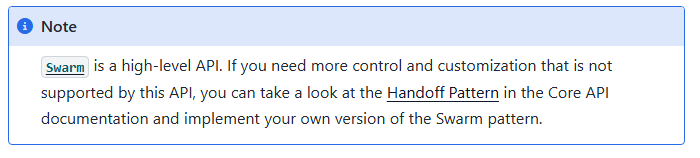

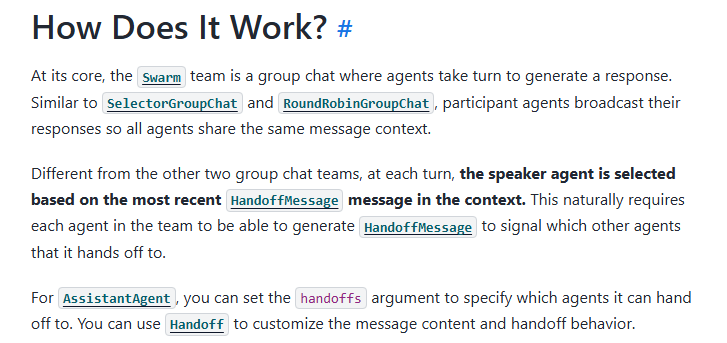 <br>

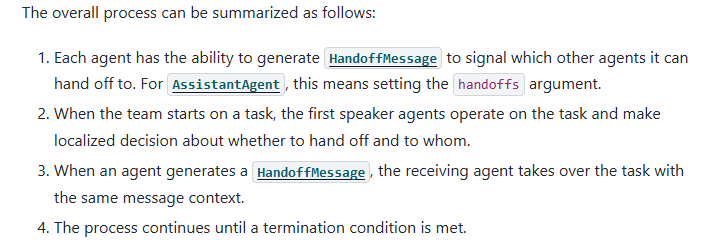

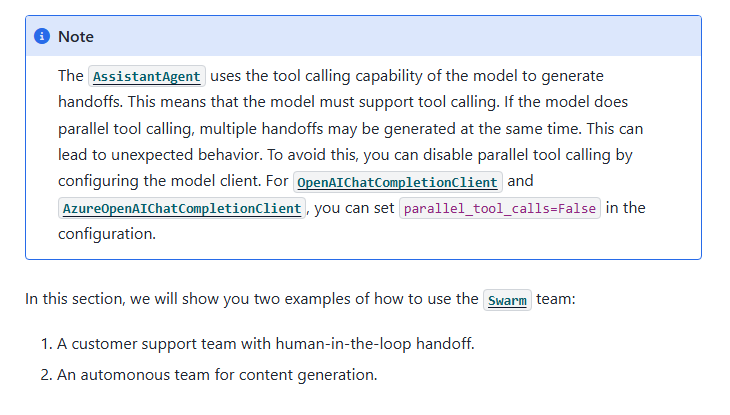

#### Reference URL

https://microsoft.github.io/autogen/stable//user-guide/agentchat-user-guide/swarm.html

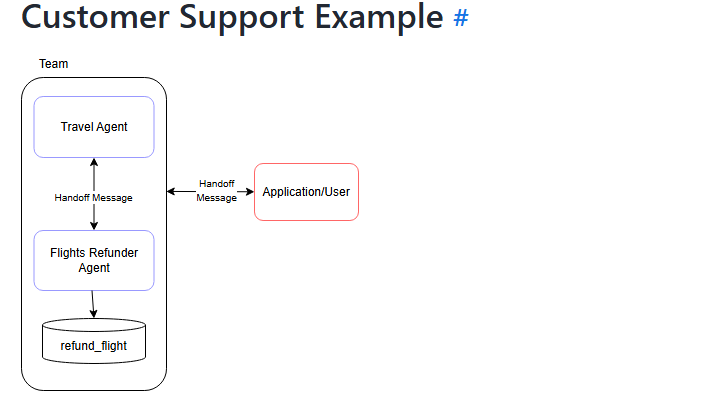 <br><br> 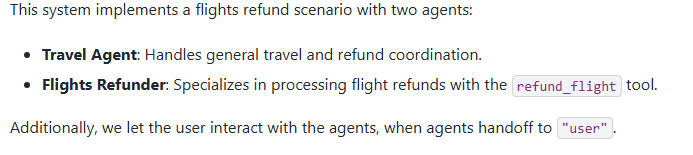 <br><br> 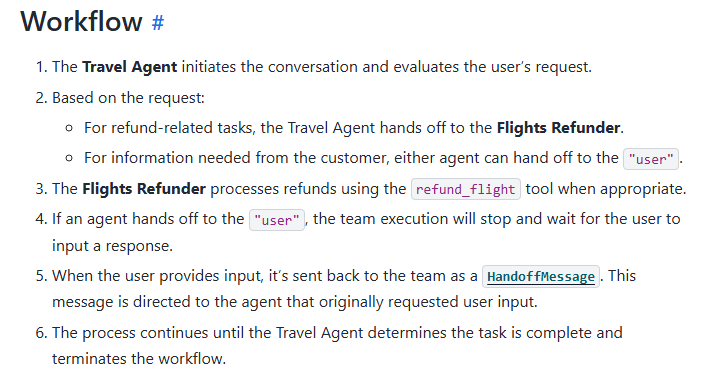



In [1]:
from typing import Any, Dict, List

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.ui import Console
from autogen_agentchat.teams import Swarm
from autogen_agentchat.conditions import TextMentionTermination, HandoffTermination
from autogen_agentchat.messages import HandoffMessage
from autogen_ext.models.openai import OpenAIChatCompletionClient

In [9]:
import os
from dotenv import load_dotenv

# Load API Key
load_dotenv()

api_key= os.getenv("OPENAI_API_KEY")

In [7]:
# Model Client

model_client= OpenAIChatCompletionClient(model='gpt-4o', api_key=api_key)

model_client

#### Tools

In [8]:
def refund_flight(flight_PNR: str) -> str:
    return f"Refunded Flight with PNR {flight_PNR}"

#### Travel Agents

In [16]:
travel_agents= AssistantAgent(
    name='travel_agents',
    model_client=model_client,
    handoffs=["flights_refunder", "user"],
    system_message="""You are a travel agent.
    The flights_refunder is in charge of refunding flights.
    If you need information from the user, you must first send your message, then you can handoff to the user.
    Use TERMINATE when the travel planning is complete."""
)

In [17]:
flights_refunder= AssistantAgent(
    name="flights_refunder",
    model_client=model_client,
    handoffs=["Travel_Agent", "user"],
    tools=[refund_flight],
    system_message="""You are an agent specialized in refunding flights.
    You only need flight PNR numbers to refund a flight.
    You have the ability to refund a flight using the refund_flight tool.
    If you need information from the user, you must first send your message, then you can handoff to the user.
    When the transaction is complete, handoff to the travel agent to finalize."""
)

#### Termination Condition

In [18]:
termination= HandoffTermination(target="user") | TextMentionTermination("TERMINATE")

#### Swarm teams

In [19]:
teams= Swarm(
    [travel_agents, flights_refunder],
    termination_condition= termination
    )

#### Reset Swarm Team

In [20]:
await teams.reset()

In [21]:
task= 'I want to refund my flight'
task_result = await Console(teams.run_stream(task=task))

---------- TextMessage (user) ----------
I want to refund my flight
---------- ToolCallRequestEvent (travel_agents) ----------
[FunctionCall(id='call_i1SLEOT4zd6uWQenhj5jbu6A', arguments='{}', name='transfer_to_flights_refunder')]
---------- ToolCallExecutionEvent (travel_agents) ----------
[FunctionExecutionResult(content='Transferred to flights_refunder, adopting the role of flights_refunder immediately.', name='transfer_to_flights_refunder', call_id='call_i1SLEOT4zd6uWQenhj5jbu6A', is_error=False)]
---------- HandoffMessage (travel_agents) ----------
Transferred to flights_refunder, adopting the role of flights_refunder immediately.
---------- TextMessage (flights_refunder) ----------
I can help you with that. Could you please provide me with your flight PNR number?
---------- ToolCallRequestEvent (flights_refunder) ----------
[FunctionCall(id='call_tSJfB84GdORgdPXZQD2uvSan', arguments='{}', name='transfer_to_user')]
---------- ToolCallExecutionEvent (flights_refunder) ----------
[F

In [22]:
task_result

TaskResult(messages=[TextMessage(id='36585354-442b-40bd-8d4a-da3a1dc53d86', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 23, 56, 563195, tzinfo=datetime.timezone.utc), content='I want to refund my flight', type='TextMessage'), ToolCallRequestEvent(id='5fc4822a-b242-438b-9d8c-901ea9fd0744', source='travel_agents', models_usage=RequestUsage(prompt_tokens=118, completion_tokens=14), metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 23, 58, 484952, tzinfo=datetime.timezone.utc), content=[FunctionCall(id='call_i1SLEOT4zd6uWQenhj5jbu6A', arguments='{}', name='transfer_to_flights_refunder')], type='ToolCallRequestEvent'), ToolCallExecutionEvent(id='078a3de0-524a-4a25-bb69-a7d473fec103', source='travel_agents', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 23, 58, 490100, tzinfo=datetime.timezone.utc), content=[FunctionExecutionResult(content='Transferred to flights_refunder, adopting the role of flights_r

In [ ]:
TaskResult(messages=[
    
    TextMessage(id='36585354-442b-40bd-8d4a-da3a1dc53d86', 
                source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 23, 56, 563195, tzinfo=datetime.timezone.utc), 
                content='I want to refund my flight', type='TextMessage'), 
                
    ToolCallRequestEvent(id='5fc4822a-b242-438b-9d8c-901ea9fd0744', 
                         source='travel_agents', models_usage=RequestUsage(prompt_tokens=118, completion_tokens=14), metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 23, 58, 484952, tzinfo=datetime.timezone.utc), 
                         content=[FunctionCall(id='call_i1SLEOT4zd6uWQenhj5jbu6A', arguments='{}', name='transfer_to_flights_refunder')], type='ToolCallRequestEvent'), 
                         
    ToolCallExecutionEvent(id='078a3de0-524a-4a25-bb69-a7d473fec103', 
                           source='travel_agents', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 23, 58, 490100, tzinfo=datetime.timezone.utc), 
                           content=[FunctionExecutionResult(content='Transferred to flights_refunder, adopting the role of flights_refunder immediately.', name='transfer_to_flights_refunder', call_id='call_i1SLEOT4zd6uWQenhj5jbu6A', is_error=False)], type='ToolCallExecutionEvent'), 
                           
    HandoffMessage(id='d6868972-4189-49ac-ac67-12493a770035', 
                   source='travel_agents', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 23, 58, 491121, tzinfo=datetime.timezone.utc), 
                   content='Transferred to flights_refunder, adopting the role of flights_refunder immediately.', target='flights_refunder', context=[], type='HandoffMessage'), 
                   
    TextMessage(id='c4f5cb7c-675d-4ff2-a3bc-217c9ff88e4f', 
                source='flights_refunder', models_usage=RequestUsage(prompt_tokens=191, completion_tokens=20), metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 23, 59, 398887, tzinfo=datetime.timezone.utc), 
                content='I can help you with that. Could you please provide me with your flight PNR number?', type='TextMessage'), 
                
    ToolCallRequestEvent(id='663b0945-31eb-4b4a-b81d-bf3473ada47f', 
                         source='flights_refunder', models_usage=RequestUsage(prompt_tokens=214, completion_tokens=11), metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 24, 0, 282163, tzinfo=datetime.timezone.utc), 
                         content=[FunctionCall(id='call_tSJfB84GdORgdPXZQD2uvSan', arguments='{}', name='transfer_to_user')], type='ToolCallRequestEvent'), 
                         
    ToolCallExecutionEvent(id='00fabca2-fb1f-4030-a4ed-9fbc1f37d992', 
                           source='flights_refunder', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 24, 0, 287621, tzinfo=datetime.timezone.utc), 
                           content=[FunctionExecutionResult(content='Transferred to user, adopting the role of user immediately.', name='transfer_to_user', call_id='call_tSJfB84GdORgdPXZQD2uvSan', is_error=False)], type='ToolCallExecutionEvent'),
    
    HandoffMessage(id='16018961-3df9-46e0-a4a5-7b5da6180dba', 
                   source='flights_refunder', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 27, 10, 24, 0, 287621, tzinfo=datetime.timezone.utc), 
                   content='Transferred to user, adopting the role of user immediately.', target='user', context=[], type='HandoffMessage')], 
           
           
    stop_reason='Handoff to user from flights_refunder detected.')